In [4]:
#!pip install gensim
import tensorflow as tf
from tensorflow import keras
from keras.datasets import imdb
from gensim.models import Word2Vec
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

### Zadanie 5

In [6]:
sentences = [
    ["pies", "jest", "duzym", "brązowym", "zwierzęciem"],
    ["kot", "jest", "małym", "szarym", "zwierzęciem"],
    ["słoń", "jest", "ogromnym", "szarym", "zwierzęciem"],
    ["mysz", "jest", "malutkim", "białym", "zwierzęciem"],
    ["lew", "jest", "dużym", "żółtym", "zwierzęciem"],
    ["pies", "i", "kot", "to", "popularne", "zwierzęta", "domowe"],
    ["słoń", "i", "lew", "żyją", "w", "Afryce"],
    ["mysz", "i", "królik", "są", "małymi", "zwierzętami"],
    ["królik", "jest", "małym", "białym", "zwierzęciem"],
    ["niedźwiedź", "jest", "dużym", "brązowym", "zwierzęciem"],
    ["czerwony", "kolor", "jest", "ciepłym", "kolorem"],
    ["niebieski", "kolor", "jest", "zimnym", "kolorem"],
    ["zielony", "kolor", "kojarzony", "jest", "z", "naturą"],
    ["żółty", "kolor", "jest", "jasnym", "i", "ciepłym"],
    ["czarny", "i", "biały", "to", "przeciwne", "kolory"],
    ["duży", "słoń", "ma", "ogromne", "uszy"],
    ["mały", "kot", "śpi", "na", "kanapie"],
    ["ogromny", "niedźwiedź", "szuka", "jedzenia", "w", "lesie"],
    ["malutka", "mysz", "chowa", "się", "przed", "kotem"],
    ["duży", "pies", "biega", "po", "parku"],
] * 100

In [8]:
w2v = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=1, epochs=100, seed=42)
words = list(w2v.wv.key_to_index.keys())
vectors = np.array([w2v.wv[w] for w in words])
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

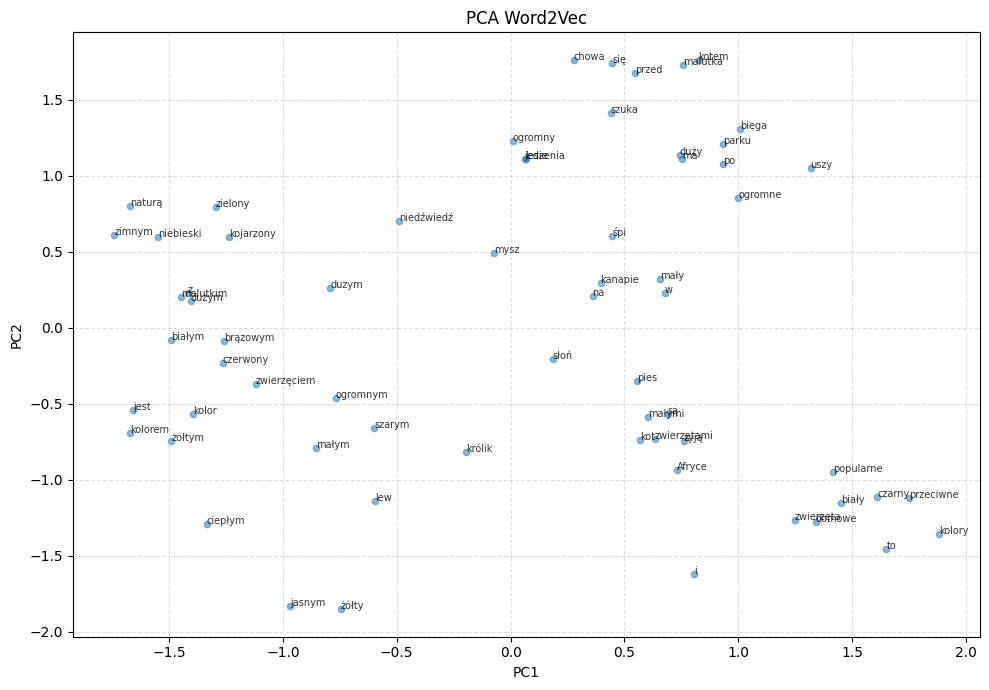

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5, s=20)

for word, (x, y) in zip(words, vectors_2d):
    ax.annotate(word, (x, y), fontsize=7, alpha=0.8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Word2Vec")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()